In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

In [4]:
nzx_tickers = [
    "FPH.NZ",  # Fisher & Paykel Healthcare
    "AIR.NZ",  # Air New Zealand
    "SPK.NZ",  # Spark
    "AIA.NZ",  # Auckland Airport
    "MEL.NZ",  # Meridian Energy
    "MCY.NZ",  # Mercury Energy
    "CEN.NZ",  # Contact Energy
    "GNE.NZ",  # Genesis Energy
    "CNU.NZ",  # Chorus
    "ARG.NZ",  # Argosy Property
]


In [26]:
# Plot Stock Prices

def plot_stock_prices(tickers, start_date, end_date):
    """
    Fetches stock price data for specified tickers over a date range and plots the prices.

    Parameters:
        tickers (list of str): Stock tickers to retrieve data for.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
    """
    # for ticker in tickers:
    #    print(f"Currency : {yf.Ticker(ticker).info['currency']}")


    # Fetch historical data for each ticker
    stock_data = yf.download(tickers, start=start_date, end=end_date)['Close']

    # line style help with grey scale
    line_styles = ['-', ':', '--', '-.']


    # Plot the stock price data
    plt.figure(figsize=(10, 6))
    for i, ticker in enumerate(tickers):
        style = line_styles[i % len(line_styles)]
        plt.plot(stock_data.index, stock_data[ticker], linestyle=style, label=ticker)

    # Adding labels and title
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.title(f'Stock Prices from {start_date} to {end_date}')
    plt.legend()
    plt.grid(True)

    plt.show()





[*********************100%***********************]  10 of 10 completed


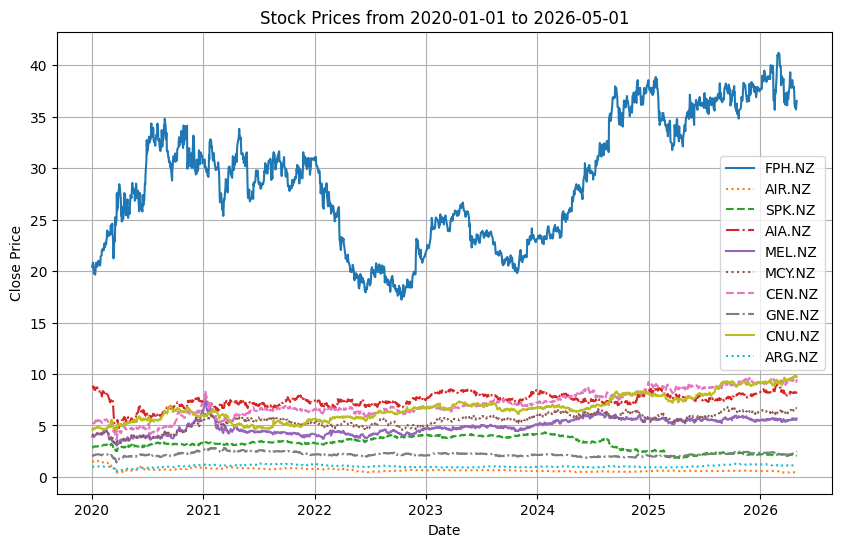

In [27]:
start_date = "2020-01-01"
end_date = "2026-05-01"
plot_stock_prices(nzx_tickers, start_date, end_date)

In [ ]:
# Fetch NZX Data
def fetch_nzx_data(tickers):
    rows = []

    for symbol in tickers:
        t = yf.Ticker(symbol)

        # info = t.fast_info
        full = t.info  # fallback for dividend


        # market_cap = info.get("market_cap")
        # price = info.get("last_price")
        price = (
            full.get("currentPrice") or
            full.get("regularMarketPrice") or
            full.get("previousClose")
        )
        market_cap = (full.get("marketCap")
                        or info.get("market_cap")
                        or price * info.get("sharesOutstanding", 0)
        )
        dividend_yield = full.get("dividendYield")

        rows.append({
            "Ticker": symbol,
            "Price": price,
            "MarketCapBillions": market_cap / 1e9,  # Convert to billions
            "DividendYield": dividend_yield
        })

    return pd.DataFrame(rows)

In [12]:
print(fetch_nzx_data(nzx_tickers))

   Ticker   Price  MarketCap  DividendYield
0  FPH.NZ  35.750  20.995582           1.18
1  AIR.NZ   0.430   1.390432           5.95
2  SPK.NZ   2.080   3.931427           9.76
3  AIA.NZ   8.390  14.222138           1.61
4  MEL.NZ   5.910  15.595149           3.66
5  MCY.NZ   6.800   9.638273           3.60
6  CEN.NZ   9.790   9.735412           3.98
7  GNE.NZ   2.480   2.792910           5.87
8  CNU.NZ  10.040   4.356229           4.73
9  ARG.NZ   1.095   0.956455           6.10


In [16]:
nvda  = pd.Series(yf.Ticker("NVDA"))
print(nvda)

nvda  = pd.Series(yf.Ticker("NVDA").info)
print(nvda)

0    yfinance.Ticker object <NVDA>
dtype: object
address1                                                     2788 San Tomas Expressway
city                                                                       Santa Clara
state                                                                               CA
zip                                                                              95051
country                                                                  United States
phone                                                                     408 486 2000
website                                                         https://www.nvidia.com
industry                                                                Semiconductors
industryKey                                                             semiconductors
industryDisp                                                            Semiconductors
sector                                                                      Techn

In [5]:
spark  = pd.Series(yf.Ticker("SPK.NZ").info)
print(spark)

address1                                                                    Spark City
address2                                    Level 1 50 Albert Street Private Bag 92028
city                                                                          Auckland
zip                                                                               1010
country                                                                    New Zealand
phone                                                                    64 4 471 1638
website                                                      https://www.sparknz.co.nz
industry                                                              Telecom Services
industryKey                                                           telecom-services
industryDisp                                                          Telecom Services
sector                                                          Communication Services
sectorKey                                  

In [6]:
abbott  = pd.Series(yf.Ticker("ABT").info)
print(abbott)

address1                                                          100 Abbott Park Road
city                                                                       Abbott Park
state                                                                               IL
zip                                                                         60064-6400
country                                                                  United States
phone                                                                     224 667 6100
website                                                         https://www.abbott.com
industry                                                               Medical Devices
industryKey                                                            medical-devices
industryDisp                                                           Medical Devices
sector                                                                      Healthcare
sectorKey                                  

In [3]:
genesis  = pd.Series(yf.Ticker("GNE.NZ").info)


chorus = pd.Series(yf.Ticker("CNU.NZ").info)


argosy = pd.Series(yf.Ticker("ARG.NZ").info)


In [7]:
print(f"{spark.sector=}")
print(f"{abbott.sector=}")
print(f"{genesis.sector=}")
print(f"{chorus.sector=}")
print(f"{argosy.sector=}")

spark.sector='Communication Services'
abbott.sector='Healthcare'
genesis.sector='Utilities'
chorus.sector='Communication Services'
argosy.sector='Real Estate'


Currency : NZD
Currency : USD
Currency : NZD
Currency : NZD


[*********************100%***********************]  5 of 5 completed

Currency : NZD


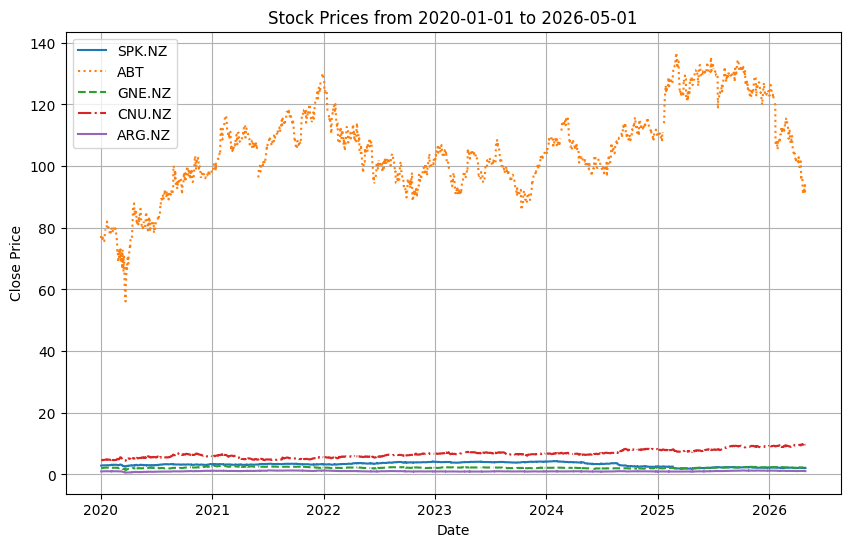

In [20]:
tickers = ["SPK.NZ", "ABT", "GNE.NZ", "CNU.NZ", "ARG.NZ"]
start_date = "2020-01-01"
end_date = "2026-05-01"
plot_stock_prices(tickers, start_date, end_date)